# The SPX Volatility Smile from Live Data

**What this notebook does:** pulls the live SPX option chain from CBOE, cleans it,
recovers a trustworthy forward price from put-call parity, and extracts the implied-volatility smile at two maturities, showing the equity skew and its term structure.

**Design principle:** nothing is hardcoded. Every date, spot, and forward is derived
from the fetch *at run time*, so this notebook produces a correct, current smile whenever
you run it today, next month, or next year. If a number looks stale, it isn't: it's live.

**The one idea to carry away:** for index options on a free data feed, the *reported*
spot price is unreliable (CBOE gates the licensed index level behind a paid feed). The
honest spot is the **forward implied by put-call parity**, recovered from the option
prices themselves, needing no external underlying quote. That single move is what makes
the whole pipeline self-contained and trustworthy.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models.bsm import bsm_price
from calibration.implied_vol import bsm_implied_vol, compute_smile
from data.option_chain import (
    fetch_chain_cboe,
    filter_by_expiry,
    clean_chain,
    find_closest_expiry,
    implied_forward_from_parity,
)

# Assumptions. r is a reasonable short-rate proxy; for production, pull the T-bill /
# SOFR curve per maturity. The dividend yield is NOT assumed here, we recover it from
# parity below, which is the whole point.
R_ANNUAL = 0.045

## 1. Sanity-check the IV inverter

Before touching real data, confirm the implied-vol inverter is correct on *synthetic*
prices where we know the answer. Price an option at a known sigma, invert, and check we
get sigma back. Also check it returns `NaN` for arbitrage-violating prices rather than a
garbage number. (Ground-truth-first: never trust an inverter on messy market data until
it round-trips on clean synthetic data.)

In [2]:
# round-trip: price at known sigma, invert, recover it
for K, opt in [(100, 'call'), (110, 'call'), (90, 'put')]:
    sigma_true = 0.25
    price = bsm_price(100, K, 1.0, 0.05, sigma_true, opt)
    sigma_back = bsm_implied_vol(price, 100, K, 1.0, 0.05, opt)
    print(f'{opt:4s} K={K}: true {sigma_true}, recovered {sigma_back:.10f}, '
          f'diff {abs(sigma_true - sigma_back):.2e}')

# arbitrage violations must return NaN, not a number
print()
print('below intrinsic ->', bsm_implied_vol(0.01, 100, 100, 1.0, 0.05, 'call'))  # NaN
print('above spot      ->', bsm_implied_vol(150.0, 100, 100, 1.0, 0.05, 'call'))  # NaN

call K=100: true 0.25, recovered 0.2500000000, diff 1.75e-13
call K=110: true 0.25, recovered 0.2500000000, diff 1.48e-14
put  K=90: true 0.25, recovered 0.2499999987, diff 1.30e-09

below intrinsic -> nan
above spot      -> nan


## 2. Fetch the live chain from CBOE

One fetch pulls *every* listed SPX contract (all expiries, calls and puts) from CBOE's
free delayed-quote feed (15-minute lag). We immediately filter to the **SPXW** root.

Why SPXW specifically: SPX (AM-settled monthly) and SPXW (PM-settled weekly) trade *at
the same strikes and expiries simultaneously*. If we don't filter to one root, we get
duplicate strikes - two different contracts at the same strike - which silently corrupts
the parity merge and the smile. SPXW has the denser, more liquid grid, so we keep it.

In [3]:
all_options, reported_spot = fetch_chain_cboe('^SPX')

print(f'Total contracts listed: {len(all_options):,}')
print(f'Distinct expiries:      {all_options["expiry"].nunique()}')
print()
print('Contracts by root:')
print(all_options['root'].value_counts())

spxw = all_options[all_options['root'] == 'SPXW'].copy()
print(f'\nAfter filtering to SPXW: {len(spxw):,} contracts')

Total contracts listed: 30,776
Distinct expiries:      57

Contracts by root:
root
SPXW    20722
SPX     10054
Name: count, dtype: int64

After filtering to SPXW: 20,722 contracts


## 3. Pick target maturities dynamically

We want two maturities to see the smile's *term structure*: a short one (~30 days) and a
longer one (~75 days). We ask the chain for the listed expiries closest to those targets
*relative to today*. Because this reads the live expiry list and today's date at run
time, it always picks sensible, currently-tradeable expiries.

In [4]:
expiries = sorted(spxw['expiry'].unique())

expiry_short, dte_short = find_closest_expiry(expiries, target_days=30)
expiry_long,  dte_long  = find_closest_expiry(expiries, target_days=75)

T_short = dte_short / 365
T_long  = dte_long / 365

print(f'Short maturity: {expiry_short}  ({dte_short} days,  T={T_short:.4f})')
print(f'Long  maturity: {expiry_long}  ({dte_long} days,  T={T_long:.4f})')
print(f'\nReported spot (CBOE current_price, UNTRUSTED): {reported_spot:.2f}')

Short maturity: 2026-07-31  (30 days,  T=0.0822)
Long  maturity: 2026-09-18  (79 days,  T=0.2164)

Reported spot (CBOE current_price, UNTRUSTED): 7499.36


## 4. Recover the forward from put-call parity, the trustworthy spot

This is the heart of the pipeline. Put-call parity says, for each strike,

$$C - P = e^{-rT}\,(F - K) \quad\Longrightarrow\quad F = K + e^{rT}(C - P).$$

Every strike where we have *both* a call and a put gives an independent estimate of the
forward $F$. On clean data these estimates agree tightly, so we take the **median** as a
noise-robust forward. This needs no external spot quote; it comes entirely from the
option prices, which is why it sidesteps the unreliable `current_price` field.

We define a small helper so we can run the same clean-and-forward step for each maturity.

In [5]:
def forward_for_expiry(chain, expiry, r, T):
    """Clean calls+puts for one expiry and return (forward, calls_clean, puts_clean, table)."""
    calls, puts = filter_by_expiry(chain, expiry)
    calls_c = clean_chain(calls, source='cboe', verbose=False)
    puts_c  = clean_chain(puts,  source='cboe', verbose=False)
    F, table = implied_forward_from_parity(calls_c, puts_c, r=r, T=T)
    return F, calls_c, puts_c, table

F_short, calls_short, puts_short, table_short = forward_for_expiry(
    spxw, expiry_short, R_ANNUAL, T_short)

# how tight is the parity forward across strikes? (the trust check)
print(f'Short-maturity parity forward: {F_short:.2f}')
print(f'  across {len(table_short)} strikes: '
      f'std {table_short["F_est"].std():.2f} '
      f'({table_short["F_est"].std()/F_short*100:.3f}% of forward)')
print(f'  reported current_price:      {reported_spot:.2f}  '
      f'(gap {abs(F_short - reported_spot):.2f})')

Short-maturity parity forward: 7504.81
  across 38 strikes: std 0.38 (0.005% of forward)
  reported current_price:      7499.36  (gap 5.45)


A `std` of a fraction of a percent across dozens of strikes means put-call parity holds
almost exactly - the quotes are clean and the forward is trustworthy. The reported spot
may or may not agree; when it's fresh it does (a nice cross-check), but we never *depend*
on it.

### Implied dividend yield, as a free by-product

The forward encodes carry: $F = S\,e^{(r-q)T}$. If we take the reported spot at face value
*just for this diagnostic*, the gap between forward and spot backs out an implied dividend
yield. For SPX this should land near ~1-2%. It's a sanity check on the whole chain, not an
input to anything.

In [6]:
# carry b such that F = S e^{bT};  then q = r - b
b_short = np.log(F_short / reported_spot) / T_short
q_implied = R_ANNUAL - b_short
print(f'implied carry b = {b_short:.4f},  implied dividend yield q = {q_implied:.2%}')
print('(sanity only - uses the untrusted spot; expect roughly 1-2% for SPX)')

implied carry b = 0.0088,  implied dividend yield q = 3.62%
(sanity only - uses the untrusted spot; expect roughly 1-2% for SPX)


## 5. Extract the smile at both maturities

Now invert every cleaned option to its implied vol. Two points of care:

- We invert against the **parity forward**, not `S e^{rT}`, by passing the carry `b`. This
  makes the smile *dividend-correct* - using the wrong forward tilts the whole smile.
- We plot IV against **log-moneyness** $\log(K/F)$, the natural axis: it centres the smile
  at the forward ($x=0$ is ATM-forward) and is comparable across maturities.

In [7]:
def smile_for_expiry(chain, expiry, r, T, spot_for_carry):
    """Full pipeline for one expiry: forward -> carry -> dividend-correct smile."""
    F, calls_c, puts_c, _ = forward_for_expiry(chain, expiry, r, T)
    b = np.log(F / spot_for_carry) / T
    smile = compute_smile(calls_c, spot=spot_for_carry, T=T, r=r, b=b, option_type='call')
    smile['log_moneyness'] = np.log(smile['strike'] / F)
    return smile, F

smile_short, F_short = smile_for_expiry(spxw, expiry_short, R_ANNUAL, T_short, reported_spot)
smile_long,  F_long  = smile_for_expiry(spxw, expiry_long,  R_ANNUAL, T_long,  reported_spot)

print(f'Short ({expiry_short}): {len(smile_short)} usable strikes')
print(f'Long  ({expiry_long}): {len(smile_long)} usable strikes')

Short (2026-07-31): 105 usable strikes
Long  (2026-09-18): 40 usable strikes


## 6. The smile and its term structure

We restrict the plot to a sensible log-moneyness window so illiquid deep-wing strikes
(noisy IVs from wide bid-ask spreads) don't distort the view. The window is expressed in
moneyness, not absolute strikes, so it stays correct at any spot level in the future.

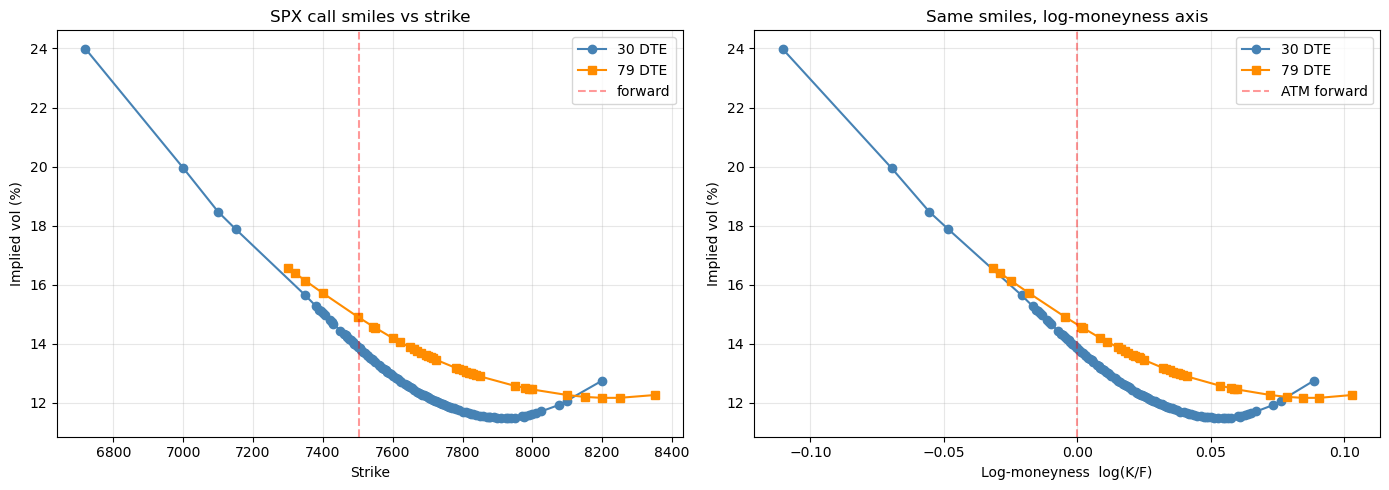

In [8]:
# moneyness window (fractional): keep strikes within roughly -12% .. +12% of forward
LM_LO, LM_HI = -0.12, 0.12

def in_window(s):
    return s[(s['log_moneyness'] >= LM_LO) & (s['log_moneyness'] <= LM_HI)]

ss, sl = in_window(smile_short), in_window(smile_long)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: IV vs strike
axes[0].plot(ss['strike'], ss['iv']*100, 'o-', color='steelblue',
             label=f'{dte_short} DTE')
axes[0].plot(sl['strike'], sl['iv']*100, 's-', color='darkorange',
             label=f'{dte_long} DTE')
axes[0].axvline(F_short, color='red', ls='--', alpha=0.4, label='forward')
axes[0].set_xlabel('Strike'); axes[0].set_ylabel('Implied vol (%)')
axes[0].set_title('SPX call smiles vs strike')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: IV vs log-moneyness (the comparable axis)
axes[1].plot(ss['log_moneyness'], ss['iv']*100, 'o-', color='steelblue',
             label=f'{dte_short} DTE')
axes[1].plot(sl['log_moneyness'], sl['iv']*100, 's-', color='darkorange',
             label=f'{dte_long} DTE')
axes[1].axvline(0, color='red', ls='--', alpha=0.4, label='ATM forward')
axes[1].set_xlabel('Log-moneyness  log(K/F)'); axes[1].set_ylabel('Implied vol (%)')
axes[1].set_title('Same smiles, log-moneyness axis')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## What to read off these plots

- **The smile is real and skewed.** IV rises as strike falls (left wing steeper than
  right) - the classic *equity skew*, driven by demand for downside crash protection.
  A constant-sigma BSM world would give a flat line here; it doesn't, which is the entire
  motivation for local vol, Heston, jumps, and rough vol.
- **Term-structure flattening.** The shorter maturity has a *steeper* skew than the longer
  one - the near-dated smile is more curved, the far-dated flatter. This is the empirical
  fact that Markovian stochastic-vol models (Heston) struggle to fit and that rough
  volatility was introduced to explain.

Because everything here is derived live, re-running this on a different day shows you the
*current* market smile - and the same structural features should persist even as the
absolute levels move.